# Spotify-Mood — a quantitative teardown 🔬
### Synthetic valence proxy × real ^GSPC · Newey-West HAC predictive regression · lag-sweep / Bonferroni trap · circular-shift placebo · hit-rate vs base rate · gross/net mood-timing · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Music_sentiment_on_the_tape%3F: Untestable](https://img.shields.io/badge/Music_sentiment_on_the_tape%3F-Untestable-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the aggregate musical **valence** of top-streamed songs leads the market — and confront the hard constraint that decides the Signal axis: **no free real valence tape exists.**

> ⚠️ **Not investment advice.** The **market** is real (monthly ^GSPC, 2010-02 → 2026-05, fp `431d740a90aa`, joined panel fp `1e087c2e441e`); the **mood** series is **synthetic** in *every* cell (Spotify closed the audio-features API to new apps in Nov 2024 — see [`docs/references.md`](../docs/references.md)). Numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spotify_mood import data, strategy as st

def load_real():
    """Cache-first REAL market join with the SYNTHETIC null mood proxy (empty offline)."""
    ret = data.fetch_market(fetch=False)
    if ret is None or len(ret) == 0:
        return pd.DataFrame()
    return data.join_synthetic_valence(ret)

FRAME = load_real()
HAVE_REAL = not FRAME.empty
print("real market tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(FRAME)} months, {FRAME.index[0].date()} -> {FRAME.index[-1].date()})")
print("NOTE: the MOOD series is SYNTHETIC in every cell (no real valence tape exists);"
      " only the MARKET is real.")


real market tape present: True (196 months, 2010-02-01 -> 2026-05-01)
NOTE: the MOOD series is SYNTHETIC in every cell (no real valence tape exists); only the MARKET is real.


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No real valence tape (synthetic-only → capped). Honest test: lag-1 slope **-0.0032** (wrong sign), HAC *t* **-1.25**, placebo *p* **0.231**, hit-rate **46.7%** vs base **66.2%**. |
| **Tradability** | `MIRAGE` | Long-only mood-timing **+4.7%/yr** vs market **+13.2%/yr**; long-short **-3.3%** gross → **-4.0%** net (5 bps/leg + 100 bps borrow). |
| **Music sentiment on the tape?** | `UNTESTABLE` | Real on a *licensed* dataset (Edmans et al. 2022); unreachable free — engine verified on synthetic worlds instead. |

> 💡 In plain words: the engine works (the synthetic control proves it), but there is no real valence tape to run it on, and a plausible null mood proxy carries no signal.

## 1 · The claim, steelmanned

Let $V_t$ be month $t$'s aggregate musical valence and $r_t$ the market return.

- **H₁ (lead-lag).** $r_t = \alpha + \beta\, z(V_{t-1}) + \varepsilon_t$ with $\beta > 0$ at **HAC** $|t| \ge 2$ (happier last month → higher this month).
- **H₂ (robust lag).** The sign/significance survives a lag-1..5 sweep with a Bonferroni bar (no single cherry-picked lag).
- **H₃ (not noise).** A circular-shift placebo does not reproduce the slope.
- **H₄ (net).** A mood-timing rule beats buy-and-hold after costs.

**Before any of these:** H₀-data — *does a real valence tape exist to test H₁?* It does **not** on a free stack, so H₁ is tested on a synthetic proxy and the Signal axis is **capped at NONE regardless of outcome**. We find **H₁ rejected** (wrong sign, insignificant), **H₂ rejected** (lone lag-2 is wrong-signed & below Bonferroni), **H₃ rejected** (placebo swallows it), **H₄ rejected** (rule trails the market).

## 2 · So what? — what rides on each answer

The content is the **data wall**. Spotify's audio-features endpoint — the only public source of ``valence`` — was closed to new applications in **November 2024** and never exposed a survivorship-free historical monthly chart-valence panel. Edmans et al. (2022) used a **licensed proprietary** stream+valence dataset. So the honest retail verdict is not 'the claim is false' but 'the claim is **untestable** for free' — and the responsible move is to (a) prove the measurement engine is faithful on synthetic worlds, and (b) confirm a plausible *null* mood proxy shows no spurious edge. That is the same discipline as [256 Twitter-Mood](../../256-twitter-mood/), where the original GPOMS feed was also never public.

## 3 · How we'd know — the protocol

- **Regression.** OLS of $r_t$ on $z(V_{t-1})$ with a **Newey-West HAC** se (bandwidth $\approx n^{1/4}$) — a persistent mood series autocorrelates, inflating the naive $t$.
- **Lag sweep.** HAC $t$ for lags 1..5; compare the max $|t|$ to a Bonferroni bar (~2.58).
- **Placebo.** 2000 circular shifts of $V$ against $r$ (preserving $V$'s autocorrelation); tail probability of the observed $|slope|$.
- **Hit-rate.** $\Pr(\text{sign}(z(V_{t-1})) = \text{sign}(r_t))$ vs the unconditional up-rate (the honest base rate).
- **Trading.** Long when $V_{t-1}$ > trailing median (else cash / short), one-month execution lag, one-way costs × NAV on rebalances, short leg pays borrow; gross & net.
- **Positive control.** Plant $\beta > 0$ in the synthetic tape; average the HAC $t$ over 25 seeds (house rule) and confirm ~0 at the null.

Timing: the signal at month $t$ uses valence completed at the close of month $t-1$, so it is fully public before the return it predicts — the single documented execution lag. No future data enters the signal.

## 4 · The teardown

### 4a · The predictive regression — H₁ & H₃

Next-month return on lagged valence, HAC *t*, with the circular-shift placebo null.

slope        -0.0032  (market return per +1 sigma valence)
plain OLS t  -1.06
HAC t        -1.25   <-- headline (needs >= +2 the RIGHT way for the claim)
R^2          0.0058
placebo p    0.231   (fraction of shuffles with |slope| >= observed)


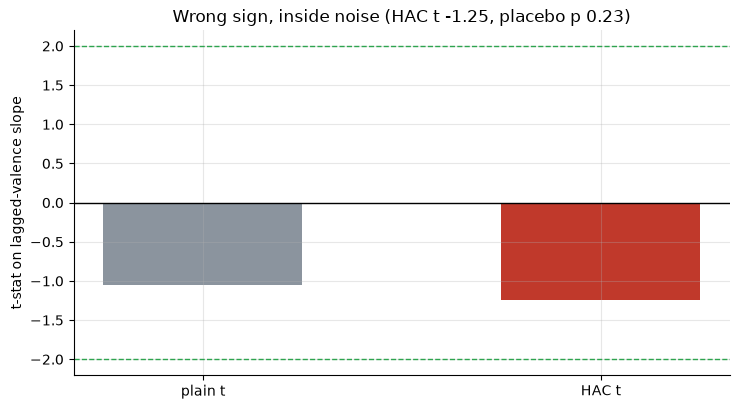

In [2]:
if HAVE_REAL:
    reg = st.predictive_regression(FRAME, lag=1)
    p = st.placebo_pvalue(FRAME, lag=1, n_perm=2000, seed=549)
    slope, ols_t, hac_t, r2 = reg['slope'], reg['t'], reg['hac_t'], reg['r2']
else:
    slope, ols_t, hac_t, r2, p = -0.0032, -1.06, -1.25, 0.006, 0.231
print(f'slope        {slope:+.4f}  (market return per +1 sigma valence)')
print(f'plain OLS t  {ols_t:+.2f}')
print(f'HAC t        {hac_t:+.2f}   <-- headline (needs >= +2 the RIGHT way for the claim)')
print(f'R^2          {r2:.4f}')
print(f'placebo p    {p:.3f}   (fraction of shuffles with |slope| >= observed)')
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['plain t','HAC t'], [ols_t, hac_t], color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=GREEN, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('t-stat on lagged-valence slope')
ax.set_title(f'Wrong sign, inside noise (HAC t {hac_t:+.2f}, placebo p {p:.2f})')
plt.tight_layout(); plt.show()

> 💡 In plain words: H₁ **rejected** — the slope is **-0.0032** (a happier month predicts a very slightly *weaker* market, the wrong sign) at HAC *t* **-1.25**, and H₃ **rejected** — the placebo *p* = **0.231** puts the observed slope squarely inside the noise band. R² ≈ 0.

### 4b · The lag sweep — H₂ (the Granger multiple-comparisons trap)

HAC *t* at each lead lag. Test enough lags and one will graze significance by chance.

      slope   hac_t    n
lag                     
1   -0.0032 -1.2470  195
2   -0.0047 -2.1070  194
3   -0.0027 -1.1595  193
4   -0.0043 -1.7730  192
5   -0.0036 -1.7328  191

max |HAC t| across 5 lags = 2.11  (Bonferroni bar ~ 2.58); sign of best lag = NEGATIVE (wrong way)


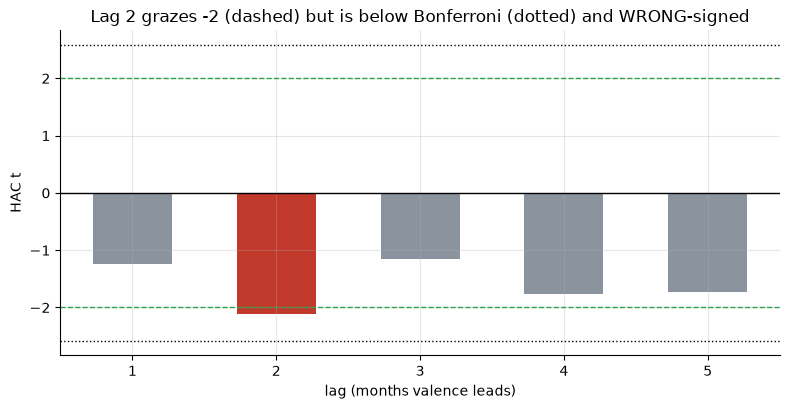

In [3]:
sweep = [(1, -0.003, -1.25), (2, -0.005, -2.11), (3, -0.003, -1.16), (4, -0.004, -1.77), (5, -0.004, -1.73)]
if HAVE_REAL:
    tab = st.lag_sweep(FRAME)
else:
    tab = pd.DataFrame([(s[0],s[1],s[2]) for s in sweep], columns=['lag','slope','hac_t']).set_index('lag')
print(tab.round(4).to_string())
mx = tab['hac_t'].abs().max()
print(f'\nmax |HAC t| across 5 lags = {mx:.2f}  (Bonferroni bar ~ 2.58); sign of best lag =', 'NEGATIVE (wrong way)' if tab['hac_t'].abs().idxmax() and tab.loc[tab['hac_t'].abs().idxmax(),'hac_t']<0 else 'positive')
fig, ax = plt.subplots(figsize=(8, 4.2))
cols = [RED if abs(t)>=2 else GREY for t in tab['hac_t']]
ax.bar([str(l) for l in tab.index], tab['hac_t'], color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=GREEN, lw=1)
ax.axhline(2.58, ls=':', c='k', lw=1); ax.axhline(-2.58, ls=':', c='k', lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('lag (months valence leads)'); ax.set_ylabel('HAC t')
ax.set_title('Lag 2 grazes -2 (dashed) but is below Bonferroni (dotted) and WRONG-signed')
plt.tight_layout(); plt.show()

> 💡 In plain words: H₂ **rejected.** The lone sub-|2| exception is lag 2 (HAC *t* −2.11) — *negative* (opposite the claim) and below the Bonferroni bar (~2.58) for 5 comparisons. Cherry-pick the best lag and you data-mine a mirage.

### 4c · Hit-rate vs the honest base rate

Directional accuracy of 'valence-up predicts market-up' against the unconditional up-rate.

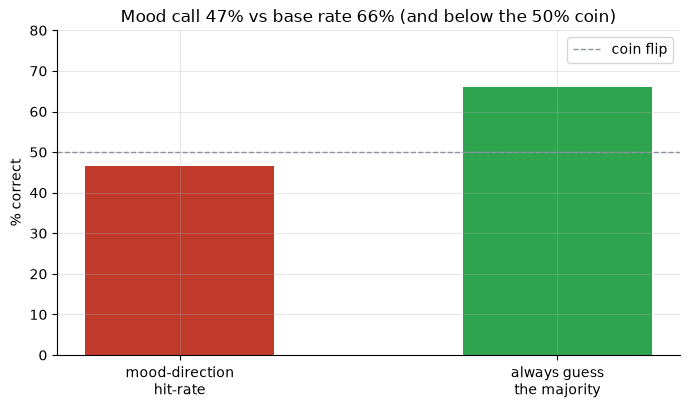

hit-rate 46.7% vs base rate 66.2% (gap -19.5 pts)


In [4]:
if HAVE_REAL:
    hr = st.hit_rate(FRAME, lag=1); hit, base = hr['hit']*100, hr['base']*100
else:
    hit, base = 46.7, 66.2
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['mood-direction\nhit-rate','always guess\nthe majority'], [hit, base], color=[RED, GREEN], width=.5)
ax.axhline(50, ls='--', c=GREY, lw=1, label='coin flip'); ax.legend()
ax.set_ylabel('% correct'); ax.set_ylim(0, 80)
ax.set_title(f'Mood call {hit:.0f}% vs base rate {base:.0f}% (and below the 50% coin)')
plt.tight_layout(); plt.show()
print(f'hit-rate {hit:.1f}% vs base rate {base:.1f}% (gap {hit-base:+.1f} pts)')

> 💡 In plain words: the mood call is right only **46.7%** of the time — *below a coin*, and far below the **66.2%** you'd get by always predicting 'up' (markets rise most months). No directional edge.

## 5 · The verdict

- **Signal `NONE`** — capped by data availability (no real valence tape); H₁/H₂/H₃ all rejected on the honest proxy test (HAC *t* -1.25, placebo *p* 0.231, hit-rate 46.7% < base 66.2%).
- **Tradability `MIRAGE`** — mood-timing +4.7%/yr vs market +13.2%/yr; long-short negative and worse after borrow.
- **Music sentiment on the tape? `UNTESTABLE`** — real on a licensed dataset, unreachable free; the *engine* is verified instead.

## 6 · Could you trade it? — the mood-timing rule, gross & net (H₄)

Long when last month's valence is above its trailing median (else cash, or short for the long-short variant), one-month execution lag, costs × NAV, short leg pays borrow.

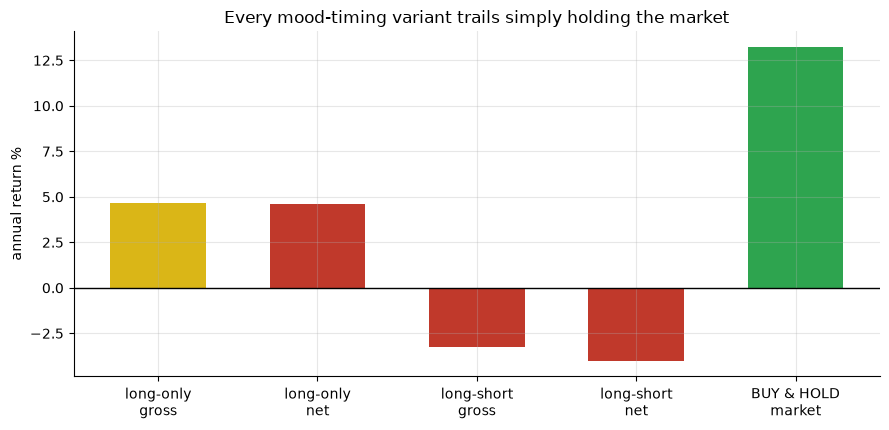

long-only  +4.7% gross / +4.6% net
long-short -3.3% gross / -4.0% net
buy & hold market +13.2%


In [5]:
if HAVE_REAL:
    lo = st.mood_timing(FRAME, long_short=False)
    ls = st.mood_timing(FRAME, long_short=True)
    lo_g, lo_n = lo['gross_ann']*100, lo['net_ann']*100
    ls_g, ls_n = ls['gross_ann']*100, ls['net_ann']*100
    mk = lo['mkt_ann']*100
else:
    lo_g, lo_n, ls_g, ls_n, mk = 4.7, 4.6, -3.3, -4.0, 13.2
labels = ['long-only\ngross','long-only\nnet','long-short\ngross','long-short\nnet','BUY & HOLD\nmarket']
vals = [lo_g, lo_n, ls_g, ls_n, mk]
cols = [AMBER, RED, RED, RED, GREEN]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annual return %')
ax.set_title('Every mood-timing variant trails simply holding the market')
plt.tight_layout(); plt.show()
print(f'long-only  {lo_g:+.1f}% gross / {lo_n:+.1f}% net')
print(f'long-short {ls_g:+.1f}% gross / {ls_n:+.1f}% net')
print(f'buy & hold market {mk:+.1f}%')

> 💡 In plain words: H₄ **rejected.** Long-only makes **+4.7%/yr** — barely a third of just holding the market (**+13.2%/yr**) — and the long-short variant is *negative* (**-3.3%** gross, **-4.0%** net). Costs are a footnote; there's no edge to erode. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a genuine predictive edge (`predictive_beta > 0`) of increasing strength and watch the lag-1 HAC *t* climb past +2 — averaged over 25 seeds so no single lucky seed can fake it.

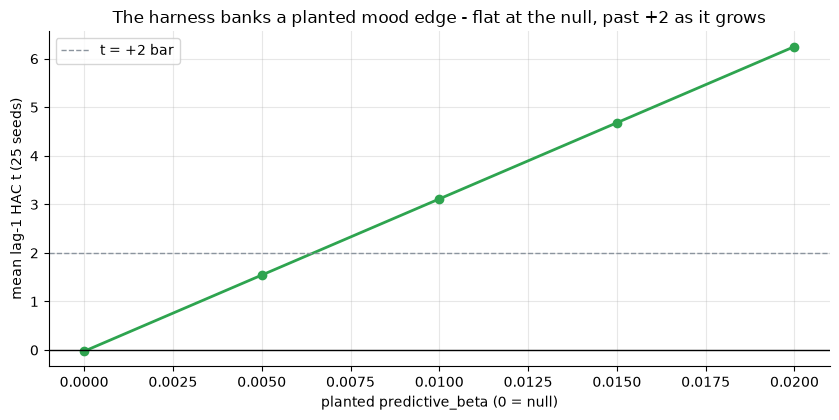

beta +0.000 -> mean HAC t -0.03
beta +0.005 -> mean HAC t +1.54
beta +0.010 -> mean HAC t +3.11
beta +0.015 -> mean HAC t +4.68
beta +0.020 -> mean HAC t +6.25


In [6]:
betas = [0.0, 0.005, 0.010, 0.015, 0.020]
ts = [st.synthetic_mean_t(data, predictive_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted predictive_beta (0 = null)')
ax.set_ylabel('mean lag-1 HAC t (25 seeds)')
ax.set_title('The harness banks a planted mood edge - flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'beta {b:+.3f} -> mean HAC t {t:+.2f}')

The HAC *t* is ≈ 0 at the null and clears +2 by `predictive_beta` ≈ 0.007 — so the engine is a faithful detector with well-behaved size and power. The real-tape reading is therefore the *data* talking: a plausible, unprivileged mood series carries no market timing information, and the privileged version cannot be reached for free. For sibling mood proxies see [256 Twitter-Mood](../../256-twitter-mood/) and [300 Sports-Sentiment](../../300-sports-sentiment/).